In [1]:
import pandas as pd 
import glob 
import analysis_utils
import numpy as np

import random


from Bio import Align


import seaborn as sns 

from pymol import cmd
from pymol import stored

from matplotlib import pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as patches

from scipy.spatial.distance import cosine

import ast
from Bio.Align import substitution_matrices


/vol/ek/Home/tomertsa/miniforge3/envs/local_python_playground/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
# one_letter["SER"] will now return "S"
one_letter ={'VAL':'V', 'ILE':'I', 'LEU':'L', 'GLU':'E', 'GLN':'Q', \
'ASP':'D', 'ASN':'N', 'HIS':'H', 'TRP':'W', 'PHE':'F', 'TYR':'Y',    \
'ARG':'R', 'LYS':'K', 'SER':'S', 'THR':'T', 'MET':'M', 'ALA':'A',    \
'GLY':'G', 'PRO':'P', 'CYS':'C'}

three_letter ={'V':'VAL', 'I':'ILE', 'L':'LEU', 'E':'GLU', 'Q':'GLN', \
'D':'ASP', 'N':'ASN', 'H':'HIS', 'W':'TRP', 'F':'PHE', 'Y':'TYR',    \
'R':'ARG', 'K':'LYS', 'S':'SER', 'T':'THR', 'M':'MET', 'A':'ALA',    \
'G':'GLY', 'P':'PRO', 'C':'CYS'}

def string_of_chars_to_joined_string(comp_str):
    if comp_str == '-':
        return comp_str
    else:
        clean_chars = [c for c in comp_str if c.isalpha()]

        # Join them together
        result = ''.join(clean_chars)
        return result

def parse_comp_position_strings(comp_str):
    # take a string of del \ sp_comp residues made by pymol selection, and parse to a list of numbers 
    print(comp_str)
    if comp_str == "-":
        return comp_str 
    else:
        parsed_comp = [item[1] for item in ast.literal_eval(comp_str)]
    
    return parsed_comp

def mane_iso_sp_region_ss2_cosine_sim(aligned_mane, aligned_iso, ss2_ratio_tab):
    """
    Calculate cosine similarity between two numpy arrays.
    
    Args:
        array1 (np.ndarray): First input array
        array2 (np.ndarray): Second input array of same length as array1
        
    Returns:
        float: Cosine similarity between the arrays (between -1 and 1)
    """
    # scipy.spatial.distance.cosine returns distance, which is 1 - similarity
    # so we subtract from 1 to get the actual similarity
    
    print(aligned_mane)
    print(aligned_iso)
    mane_ss2_arr = np.array(ss2_ratio_tab.query('index == @aligned_mane').iloc[0].tolist(),dtype='float')
    iso_ss2_arr = np.array(ss2_ratio_tab.query('index == @aligned_iso').iloc[0].tolist(),dtype='float')
    
    
    print(mane_ss2_arr)
    print(iso_ss2_arr)
    cos_sim = 1-cosine(mane_ss2_arr, iso_ss2_arr)
    
    print(cos_sim)
    return cos_sim

def find_corresponding_positions(array1, array2):
    # Find positions in array1 that correspond to -1 in array2
    # add +1 to each position to move from 0-based python to 1-based AA number  

    return [(i+1) for i, val in enumerate(array2) if val == -1]


def make_pymol_align_session(aligned_mane, aligned_iso, mane_sp_end, iso_sp_end, mane_del, iso_del, dist_cutoff=3):
    cmd.delete('all')
    
#     cmd.extend('get_colors',get_colors)
#     cmd.extend('get_lighting', get_lighting)
    
#     session_palette = ["1262A0","E7C686","BF986E","8DAFBE","C14C3A"]
    cmd.set("cartoon_gap_cutoff", 0)
    
    cmd.set_color("mane_domain",       [18,98,160])
    cmd.set_color("iso_sp",      [244,217,149])
    cmd.set_color("mane_sp",     [178,130,84])
    cmd.set_color("iso_domain",      [141,175,190])
    cmd.set_color("deletion",       [193,76,58])
    
    
    cmd.do('set specular, 0')
    cmd.do('set ray_shadow, off')
    cmd.do('set valence, off')
    cmd.do('set antialias, 2')
    cmd.do('set ray_trace_mode, 1')
    cmd.do('set ray_trace_disco_factor, 1')
    cmd.do('set ray_trace_gain, 0.1')
    cmd.do('set power, 0.2')
    cmd.do('set ambient, 0.4')
    cmd.do('set ray_trace_color, gray30')
    
    
    chess_path = "/sci/labs/fora/share/databases/CHESS_v3_db/pdb_v1.3/"
    mane_pdb = chess_path+aligned_mane+'.pdb'
    iso_pdb = chess_path+aligned_iso+'.pdb'
    
    cmd.load(mane_pdb)
    cmd.load(iso_pdb)

    ##### superposition of iso to mane #####
    # First attempt: align full chains
    align_result = cmd.super(aligned_iso, aligned_mane)
    rmsd = align_result[0]
    nterm_rmsd = None
    
    print(aligned_mane)
    print(aligned_iso)
    print(rmsd)
    
    iso_len_sele = f"{aligned_iso} and name CA"
    iso_len = cmd.count_atoms(iso_len_sele)
    print("iso_len")
    print(iso_len)
    
    # If RMSD is too high, try aligning just the first 100 residues
    rmsd_list = []    
    nterm_len_list = [100,50, iso_len]   
    print(f"Initial alignment RMSD ({rmsd:.2f}) > 10Å.")
    for nterm_cutoff in nterm_len_list:
        # Create new selections for first 100 residues of chain B
        iso_start = f"{aligned_iso} and resi 1-{nterm_cutoff}"

        # Perform new alignment
        align_result = cmd.super(iso_start, aligned_mane)
        nterm_rmsd = align_result[0]
        rmsd_list.append(nterm_rmsd)
        print(f"New alignment RMSD: {nterm_rmsd:.2f}Å")
    
    print('rmsd_list')
    print(rmsd_list)
    print(rmsd_list.index(min(rmsd_list)))
    best_super = rmsd_list.index(min(rmsd_list))
    nterm_cutoff = nterm_len_list[best_super] 
    iso_start = f"{aligned_iso} and resi 1-{nterm_cutoff}"
    align_result = cmd.super(iso_start, aligned_mane)
    nterm_rmsd = align_result[0]


    ##### sp and deletion selections and coloring #####
    
    # variable recording the complemented \ complementing seq, initialized 
    del_comp_pos = None
    sp_comp_pos = None
    del_comp_seq = None
    sp_comp_seq = None
    
    # base coloring of iso and mane
    cmd.color("mane_domain", aligned_mane)
    cmd.color("iso_domain", aligned_iso)
    cmd.color("mane_sp", f"{aligned_mane} and resi 1-{mane_sp_end}")
    
    iso_sp_selection = f"{aligned_iso} and resi 1-{iso_sp_end}"
    cmd.color("iso_sp", iso_sp_selection)
    
    
    # if there is a deletion in iso (len>1), select it and color red 
    iso_selection = "+".join(str(x) for x in iso_del)
    if len(iso_selection) >=1:
        cmd.color("deletion", f"{aligned_iso} and resi {iso_selection}")
   
    # if there is a deletion in mane (len>1), select it and color red     
    mane_selection = "+".join(str(x) for x in mane_del)
    if len(mane_selection) >=1:
        mane_del_selection = f"{aligned_mane} and resi {mane_selection}"
        cmd.color("deletion", mane_del_selection)
        
        # compute the min_rmsd value between iso sp and mane deletion
        min_rmsd = get_min_ca_rmsd(mane_del_selection, iso_sp_selection)
        
        # detect the deleted part being complemented by sp, and sp part complemeting the deletion
        
        mane_del_selection_and_CA = mane_del_selection + ' and name CA'
        iso_sp_selection_and_CA = iso_sp_selection + ' and name CA'
        
        cmd.select("mane_del_selection", mane_del_selection)
        cmd.select("iso_sp_selection", iso_sp_selection)
        
        cmd.select("mane_del_selection_and_CA", mane_del_selection_and_CA)
        cmd.select("iso_sp_selection_and_CA", iso_sp_selection_and_CA)
        
        
#         cmd.select("del_comp_residues", f"byres (mane_del_selection within {dist_cutoff} of iso_sp_selection)")
#         cmd.select("sp_comp_residues", f"byres (iso_sp_selection within {dist_cutoff} of del_comp_residues)")
        
        
        del_comp_residues = f"bycalpha (mane_del_selection_and_CA within {dist_cutoff} of iso_sp_selection_and_CA)"
        sp_comp_residues = f"bycalpha (iso_sp_selection_and_CA within {dist_cutoff} of del_comp_residues)"
        
        cmd.select("del_comp_residues", del_comp_residues)
        cmd.select("sp_comp_residues", sp_comp_residues)
        
        
        
        del_comp_len = cmd.count_atoms('del_comp_residues and name CA')
        sp_comp_len = cmd.count_atoms('sp_comp_residues and name CA')
        print('del_comp_len')
        print(del_comp_len)
        print('sp_comp_len')
        print(sp_comp_len)
        
        if del_comp_len >= 1:
            
            cmd.create("del_comp_obj", "del_comp_residues")
            cmd.color("white", "del_comp_obj")
            
            cmd.create("sp_comp_obj", "sp_comp_residues")
            cmd.color("white", "sp_comp_obj")
            
            del_comp_pos, del_comp_seq = get_residue_info(del_comp_residues)
            sp_comp_pos, sp_comp_seq = get_residue_info(sp_comp_residues)
            
    
    else: 
        min_rmsd = -1
         
    ## set picture params 
    
    cmd.center(iso_start)
    cmd.orient(iso_start)
    cmd.zoom(iso_start, buffer=10.0)
    
    # Set transparent background
    cmd.set("ray_opaque_background", "off")
    # Set resolution (300 DPI)
    # Convert DPI to pixels (assuming 4 inches width)
    width = 3 * 300  # 1200 pixels
    height = 3 * 300  # 1200 pixels
    cmd.viewport(width, height)

    # Generate ray-traced image and save
    cmd.ray(width, height)
    
    pymol_output_path = "/vol/ek/Home/tomertsa/projects/signal_peptide/chs_refseq_approach/figures_and_reports/aligned_pymol_sessions/second_version_on_identical_nterm_segment/"
    
#     cmd.png(f"{pymol_output_path}new_aligned_session_{aligned_mane}_{aligned_iso}.png", dpi=300)
    
    
    ### save sessions and return 
    cmd.save(f"{pymol_output_path}new_aligned_session_{aligned_mane}_{aligned_iso}.pse")

    cmd.delete('all')
    return rmsd, nterm_rmsd, min_rmsd, del_comp_pos, del_comp_seq, sp_comp_pos, sp_comp_seq


def get_residue_info(selection):
    # Clear any previous data
    stored.residues = []
    stored.resnames = []
    
    # Iterate through selection to collect residue numbers and names
    cmd.iterate(f"{selection} and name CA", "stored.residues.append(resi); stored.resnames.append(resn)")
    
    # Process the residue lists - convert to integers, remove duplicates, and sort
    unique_residues = []
    unique_resnames = []
    
    # Create a dictionary of {residue_number: residue_name}
    res_map = {}
    for resi, resn in zip(stored.residues, stored.resnames):
        res_map[int(resi)] = resn
    
    # Get sorted unique residue numbers
    sorted_res_nums = sorted(([int(x) for x in stored.residues]))
    print('stored.residues')
    print(stored.residues)
    print('stored.resnames')
    print(stored.resnames)
    
    print('sorted res nums')
    print(sorted_res_nums)
    
    # Build the corresponding resname list
    for resi in sorted_res_nums:
        unique_resnames.append(res_map[resi])
    
    one_letter_unique_resnames = [one_letter[x] for x in unique_resnames]
    
    return sorted_res_nums, one_letter_unique_resnames

# Usage example:
# del_res, del_names = get_residue_info("del_comp_residues")
# sp_res, sp_names = get_residue_info("sp_comp_residues")

    
def get_min_ca_rmsd(sel1, sel2):
    # Get list of Calpha atoms from each selection
    ca1 = cmd.get_model(f"{sel1} and name CA").atom
    ca2 = cmd.get_model(f"{sel2} and name CA").atom
    
    min_rmsd = float('inf')
    
    # Compare each residue pair
    for atom1 in ca1:
        pos1 = atom1.coord
        for atom2 in ca2:
            pos2 = atom2.coord
            # Calculate RMSD between single pair of atoms
            dist = sum((a - b) ** 2 for a, b in zip(pos1, pos2))
            rmsd = (dist / 1) ** 0.5  # Divide by 1 since it's a single atom pair
            min_rmsd = min(min_rmsd, rmsd)
            
    return min_rmsd

def make_alignment(aligned_mane, aligned_iso):
    aligned_mane_seq = chs_fasta_table.query('CHESS_ID == @aligned_mane').Sequence.iloc[0]
    aligned_iso_seq = chs_fasta_table.query('CHESS_ID == @aligned_iso').Sequence.iloc[0]
    
    aln = analysis_utils.pairwise_align(aligned_mane_seq, aligned_iso_seq)
    print(aln[0])
    return aln    
    
def get_consecutive_ranges(numbers):
    if not numbers:
        return []
    
    # Sort the list to ensure we process numbers in order
    numbers = sorted(numbers)
    
    ranges = []
    start = numbers[0]
    end = numbers[0]
    
    for i in range(1, len(numbers)):
        if numbers[i] == end + 1:
            # Current number continues the sequence
            end = numbers[i]
        else:
            # Sequence is broken, add the current range and start a new one
            ranges.append((start, end))
            start = numbers[i]
            end = numbers[i]
    
    # Add the last range
    ranges.append((start, end))
    
    return ranges

def extract_del_regions(aln):
    
    # from the alignment object, extract the positions of deletions 
    del_freq = aln[0].frequencies['-']
    del_target_pos = np.where(del_freq==1)[0].tolist()
    
    # add 1 to all, to convert 0-based python to 1-based sequence numbering 
    del_target_pos_1based = [i+1 for i in del_target_pos]
    
    del_target_pos_1based_range_tuples = get_consecutive_ranges(del_target_pos_1based)
    print('del_target_pos')
    print(del_target_pos)
    print('del_target_pos_1based')
    print(del_target_pos_1based)
    
    print(del_target_pos_1based_range_tuples)
    return del_target_pos_1based_range_tuples

# def verify_del_indices():


def get_sp_coverage(tm_align_tab, sp_end):
    df = tm_align_tab
    sp_pos_str = [str(x) for x in range(sp_end)]
    sp_aligned_chain2 = df[df['Chain1_Position'].isin(sp_pos_str)].Chain2_Position
    sp_bool = pd.Series(sp_aligned_chain2).isin(sp_pos_str)
    
#     print('chain1 positions ')
    print(df[df['Chain1_Position'].isin(sp_pos_str)])
    mutual_sp_align_ratio = sum(sp_bool)/len(sp_bool)
    
#     print(mutual_sp_align_ratio)
    return mutual_sp_align_ratio


def define_sp_regions(aligned_mane, aligned_iso, del_target_pos):
    
    #Make sure that indeed there is a signalp prediction 
    if len(inclusive_sp_general_tab.query('CHESS_ID == @aligned_mane').CS_pos) == 0:
        aligned_mane_sp = "-1"
        mane_sp_confidence = "0"
    else:
        aligned_mane_sp = str(inclusive_sp_general_tab.query('CHESS_ID == @aligned_mane').CS_pos.iloc[0])
        mane_sp_confidence = inclusive_sp_general_tab.query('CHESS_ID == @aligned_mane')['SP(Sec/SPI)'].iloc[0]
    # No need to check for iso, since they are all by definition with sp prediction 
    aligned_iso_sp = str(inclusive_sp_general_tab.query('CHESS_ID == @aligned_iso').CS_pos.iloc[0])
    iso_sp_confidence = inclusive_sp_general_tab.query('CHESS_ID == @aligned_iso')['SP(Sec/SPI)'].iloc[0]
    
    print('aligned_iso_sp')
    print(aligned_iso_sp)
    print('aligned_mane_sp')
    print(aligned_mane_sp)
    
    ## assign "corrected" sp coordinates - SP segments that are identical between MANE and isoform 
    ## fill in with "avg_sp" position when needed 
    avg_sp_pos = 23 
    last_pos_before_first_del_start = int(del_target_pos[0]) -1
    int_aligned_mane_sp = int(aligned_mane_sp)
    int_aligned_iso_sp = int(aligned_iso_sp)
    
    if aligned_mane_sp == "-1" and aligned_iso_sp == "-1":
        
        # if both mane and iso have no SignalP pred, assign the avg(e.g. 23) or the last aligned pos before del
        assigned_sp_pos = min(last_pos_before_first_del_start,avg_sp_pos)
        corrected_aligned_mane_sp = assigned_sp_pos
        corrected_aligned_iso_sp = assigned_sp_pos
        
    elif aligned_mane_sp != "-1" and aligned_iso_sp == "-1":
        # 
        assigned_sp_pos = min(last_pos_before_first_del_start,int_aligned_mane_sp)
        corrected_aligned_mane_sp = assigned_sp_pos
        corrected_aligned_iso_sp = assigned_sp_pos
        
        
    elif aligned_mane_sp == "-1" and aligned_iso_sp != "-1":
        #
        assigned_sp_pos = min(last_pos_before_first_del_start,int_aligned_iso_sp)
        corrected_aligned_mane_sp = assigned_sp_pos
        corrected_aligned_iso_sp = assigned_sp_pos
        
    
    else:
        assigned_sp_pos = min(last_pos_before_first_del_start,int_aligned_mane_sp,int_aligned_iso_sp)
        corrected_aligned_mane_sp = assigned_sp_pos
        corrected_aligned_iso_sp = assigned_sp_pos
    
    
    return aligned_mane_sp, aligned_iso_sp, mane_sp_confidence, iso_sp_confidence, \
    corrected_aligned_mane_sp, corrected_aligned_iso_sp

def get_coil_percent_full_ss2(ss_df):
    ss_percents = ss_df.residue_ss.value_counts(normalize=True) * 100
    
    return ss_percents['C']

def map_sp_complementation(aligned_mane, aligned_iso, pymol_session=False):
    print(aligned_mane)
    print(aligned_iso)
    
    # make pairwise alignment of mane and isoform with the defined params 
    aln = make_alignment(aligned_mane, aligned_iso)
    
    # get the residues of mane where a deletion exsists 
    del_target_pos = extract_del_regions(aln)
    
    # get sp region values for mane and isoform: 
        # - if signalp prediction exsits -> take it 
        # - if signalp exists for mane and not for iso - take for iso the seq identical sp part 
        # - if mane has no signalp, but isoform does, leave as is 
    aligned_mane_sp, aligned_iso_sp, mane_sp_confidence, iso_sp_confidence,\
    corrected_aligned_mane_sp, corrected_aligned_iso_sp =\
    define_sp_regions(aligned_mane, aligned_iso,del_target_pos[0])
    
    
    
    # map which positions in isoform correspond to the deletion positions in mane, and vice versa
    del_in_target = find_corresponding_positions(aln[0].indices[0],aln[0].indices[1])
    del_in_query = find_corresponding_positions(aln[0].indices[1],aln[0].indices[0])
    
    print('indices')
    print(aln[0].indices)
    print('del_in_target')
    print(del_in_target)
    print('del_in_query')
    print(del_in_query)
    
    if not pymol_session:
        results = {
            'aligned_mane': aligned_mane,
            'aligned_iso': aligned_iso,
            'mane_len': len(chs_fasta_table.query('CHESS_ID == @aligned_mane').Sequence.iloc[0]),
            'iso_len': len(chs_fasta_table.query('CHESS_ID == @aligned_iso').Sequence.iloc[0]),
    #         'aln': aln, 
            # +1 in deletion pos due to 0 based python and 1 based sequence
            'deletion_pos': del_target_pos,
            'aligned_mane_sp': aligned_mane_sp,
            'mane_sp_confidence': mane_sp_confidence,
            'aligned_iso_sp': aligned_iso_sp, 
            'iso_sp_confidence': iso_sp_confidence,
            'corrected_mane_sp': corrected_aligned_mane_sp, 
            'corrected_iso_sp': corrected_aligned_iso_sp

        }

        return results
    
    else:

        rmsd, nterm_rmsd, min_rmsd, del_comp_pos, del_comp_seq, sp_comp_pos, sp_comp_seq \
            = make_pymol_align_session(aligned_mane, aligned_iso, corrected_aligned_mane_sp, \
            corrected_aligned_iso_sp, del_in_target, del_in_query)

        full_results = {
            'aligned_mane': aligned_mane,
            'aligned_iso': aligned_iso,
            'mane_len': len(chs_fasta_table.query('CHESS_ID == @aligned_mane').Sequence.iloc[0]),
            'iso_len': len(chs_fasta_table.query('CHESS_ID == @aligned_iso').Sequence.iloc[0]),
    #         'aln': aln, 
            'deletion_pos': del_target_pos, 
            'aligned_mane_sp': aligned_mane_sp,
            'mane_sp_confidence': mane_sp_confidence,
            'aligned_iso_sp': aligned_iso_sp, 
            'iso_sp_confidence': iso_sp_confidence,
            'corrected_mane_sp': corrected_aligned_mane_sp, 
            'corrected_iso_sp': corrected_aligned_iso_sp, 
            'rmsd': rmsd,
            'nterm_rmsd': nterm_rmsd,
            'min_rmsd': min_rmsd,
            'del_comp_pos': del_comp_pos,
            'sp_comp_pos': sp_comp_pos,
            'del_comp_seq': del_comp_seq,
            'sp_comp_seq': sp_comp_seq
        }

        return full_results
    


In [3]:
# read in aligned_sp_and_deletion isoform tables 
sp_and_del = pd.read_table('aligned_sp_and_deletion_isoform_mane_table_220225.tsv',sep='\t')

# read in the chs fasta table and change CHS_ID to index 
chs_fasta_table = pd.read_table('../results/chs_fasta_table.tsv',sep='\t')
human_sp_chs_fasta_tab = pd.read_table("../results/human_sp_chs_fasta_table.tsv",sep='\t')

chs_fasta_table.set_index('CHESS_ID',inplace=True)

inclusive_sp_general_tab = pd.read_table('inclusive_sp_general_tab_120125_struct_role_domain_completion_ipynb.tsv',sep='\t')

path_to_parsed_structural_tabs = '../results/lddt_sasa_ss2_seq_processing/parsed_full_chs_lddt_sasa_ss2_seq_tables/'
ss_tab = pd.read_table(path_to_parsed_structural_tabs+'_ss_structural_tab.tsv',sep='\t')

# full ss length 
# example tab name - CHS.35724.4_sasa_lddt_ss.tsv
ss_path = "/vol/ek/Home/tomertsa/projects/signal_peptide/chs_refseq_approach/results/lddt_sasa_ss2_seq_processing/batch_by_residue_output/"

pd.set_option('display.max_rows', 125)


Text(0.5, 1.0, 'sp_and_del signalp confidence')

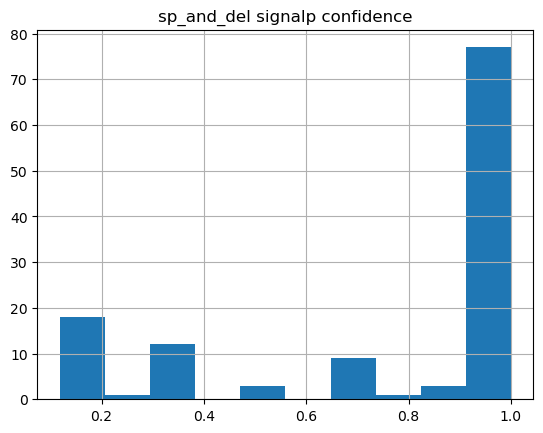

In [6]:
# get the confidence of the sp_and_del SignalP predictions 

inclusive_sp_general_tab[inclusive_sp_general_tab.CHESS_ID.isin(sp_and_del.aligned_iso)]['SP(Sec/SPI)'].hist()
plt.title('sp_and_del signalp confidence')

In [ ]:
# # run map_sp_complementation function on the whole set:
## 1. perform seq align
## 2. perform structural alignment using pymol.cmd 
## 3. create pymol sessions 
## 4. save results into table 

# t = sp_and_del.apply(lambda row: map_sp_complementation(row['aligned_mane'], row['aligned_iso'], True),axis=1)
# struct_del_align_results = pd.DataFrame(t.tolist())


# # add a GENE name column (and drop the added CHESS_ID column)
# struct_del_align_results = struct_del_align_results.merge(inclusive_sp_general_tab[['CHESS_ID','GENE']],\
#                                                           left_on = 'aligned_iso', right_on='CHESS_ID')

# struct_del_align_results.drop(['CHESS_ID'], axis=1, inplace=True)
# struct_del_align_results.to_csv('struct_del_align_results_150425.tsv',sep='\t',index=False)

CHS.35724.4
CHS.35724.alt100
target            0 MEGAALLRVSVLCIWMSALFLGVGVRAEEAGARVQQNVPSGTDTGDPQSKPLGDWAAGTM
                  0 |||||||||||||||------------------|||||||||||||||||||||||||||
query             0 MEGAALLRVSVLCIW------------------VQQNVPSGTDTGDPQSKPLGDWAAGTM

target           60 DPESSIFIEDAIKYFKEKVSTQNLLLLLTDNEAWNGFVAAAELPRNEADELRKALDNLAR
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            42 DPESSIFIEDAIKYFKEKVSTQNLLLLLTDNEAWNGFVAAAELPRNEADELRKALDNLAR

target          120 QMIMKDKNWHDKGQQYRNWFLKEFPRLKSELEDNIRRLRALADGVQKVHKGTTIANVVSG
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           102 QMIMKDKNWHDKGQQYRNWFLKEFPRLKSELEDNIRRLRALADGVQKVHKGTTIANVVSG

target          180 SLSISSGILTLVGMGLAPFTEGGSLVLLEPGMELGITAALTGITSSTMDYGKKWWTQAQA
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           162 SLSISSGILTLVGMGLAPFTEGGSLVLLEPGMELGITAALTGITSSTMDYGKKWWTQ

New alignment RMSD: 0.25Å
New alignment RMSD: 0.71Å
New alignment RMSD: 2.52Å
rmsd_list
[0.253130167722702, 0.7056344151496887, 2.5213520526885986]
0
del_comp_len
4
sp_comp_len
4
stored.residues
['16', '17', '18', '19']
stored.resnames
['MET', 'SER', 'ALA', 'LEU']
sorted res nums
[16, 17, 18, 19]
stored.residues
['10', '13', '14', '15']
stored.resnames
['SER', 'CYS', 'ILE', 'TRP']
sorted res nums
[10, 13, 14, 15]
CHS.35724.4
CHS.35724.14
target            0 MEGAALLRVSVLCIWMSALFLGVGVRAEEAGARVQQNVPSGTDTGDPQSKPLGDWAAGTM
                  0 |||||||||||||||------------------|||||||||||||||||||||||||||
query             0 MEGAALLRVSVLCIW------------------VQQNVPSGTDTGDPQSKPLGDWAAGTM

target           60 DPESSIFIEDAIKYFKEKVSTQNLLLLLTDNEAWNGFVAAAELPRNEADELRKALDNLAR
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            42 DPESSIFIEDAIKYFKEKVSTQNLLLLLTDNEAWNGFVAAAELPRNEADELRKALDNLAR

target          120 QMIMKDKNWHDKGQQYRNWFLKEFPRLKSELEDNIRRLRALADGVQKVHK

New alignment RMSD: 0.25Å
New alignment RMSD: 0.71Å
New alignment RMSD: 2.52Å
rmsd_list
[0.253130167722702, 0.7056344151496887, 2.5213520526885986]
0
del_comp_len
4
sp_comp_len
4
stored.residues
['16', '17', '18', '19']
stored.resnames
['MET', 'SER', 'ALA', 'LEU']
sorted res nums
[16, 17, 18, 19]
stored.residues
['10', '13', '14', '15']
stored.resnames
['SER', 'CYS', 'ILE', 'TRP']
sorted res nums
[10, 13, 14, 15]
CHS.38154.1
CHS.38154.2
target            0 MDPQCTMGLSNILFVMAFLLSGAAPLKIQAYFNETADLPCQFANSQNQSLSELVVFWQDQ
                  0 |||||||||||||||||||||---------------------------------------
query             0 MDPQCTMGLSNILFVMAFLLS---------------------------------------

target           60 ENLVLNEVYLGKEKFDSVHSKYMGRTSFDSDSWTLRLHNLQIKDKGLYQCIIHHKKPTGM
                 60 ------------------------------------------------------------
query            21 ------------------------------------------------------------

target          120 IRIHQMNSELSVLANFSQPEIVPISNITENVYINLTCSSIHGYPEPKKMSV

CHS.53322.4
CHS.53322.2
0.13134914636611938
iso_len
672
Initial alignment RMSD (0.13) > 10Å.
New alignment RMSD: 0.15Å
New alignment RMSD: 0.38Å
New alignment RMSD: 0.13Å
rmsd_list
[0.15432029962539673, 0.38496750593185425, 0.13134925067424774]
2
CHS.53322.4
CHS.53322.5
target            0 MSGAGRALAALLLAASVLSAALLAPGGSSGRDAQAAPPRDLDKKRHAELKMDQALLLIHN
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MSGAGRALAALLLAASVLSAALLAPGGSSGRDAQAAPPRDLDKKRHAELKMDQALLLIHN

target           60 ELLWTNLTVYWKSECCYHCLFQVLVNVPQSPKAGKPSAAAASVSTQHGSILQLNDTLEEK
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            60 ELLWTNLTVYWKSECCYHCLFQVLVNVPQSPKAGKPSAAAASVSTQHGSILQLNDTLEEK

target          120 EVCRLEYRFGEFGNYSLLVKNIHNGVSEIACDLAVNEDPVDSNLPVSIAFLIGLAVIIVI
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           120 EVCRLEYRFGEFGNYSLLVKNIHNGVSEIACDLAVNEDPVDSNLPVSIAFLIGLAVIIV

CHS.53322.4
CHS.53322.3
0.14986103773117065
iso_len
664
Initial alignment RMSD (0.15) > 10Å.
New alignment RMSD: 0.24Å
New alignment RMSD: 0.65Å
New alignment RMSD: 0.15Å
rmsd_list
[0.24162925779819489, 0.6497283577919006, 0.14986124634742737]
2
CHS.53322.4
CHS.53322.6
target            0 MSGAGRALAALLLAASVLSAALLAPGGSSGRDAQAAPPRDLDKKRHAELKMDQALLLIHN
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MSGAGRALAALLLAASVLSAALLAPGGSSGRDAQAAPPRDLDKKRHAELKMDQALLLIHN

target           60 ELLWTNLTVYWKSECCYHCLFQVLVNVPQSPKAGKPSAAAASVSTQHGSILQLNDTLEEK
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            60 ELLWTNLTVYWKSECCYHCLFQVLVNVPQSPKAGKPSAAAASVSTQHGSILQLNDTLEEK

target          120 EVCRLEYRFGEFGNYSLLVKNIHNGVSEIACDLAVNEDPVDSNLPVSIAFLIGLAVIIVI
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           120 EVCRLEYRFGEFGNYSLLVKNIHNGVSEIACDLAVNEDPVDSNLPVSIAFLIGLAVIIVI

...

CHS.39979.27
CHS.39979.alt104
0.3288337290287018
iso_len
825
Initial alignment RMSD (0.33) > 10Å.
New alignment RMSD: 0.32Å
New alignment RMSD: 0.77Å
New alignment RMSD: 0.33Å
rmsd_list
[0.32334840297698975, 0.7687957286834717, 0.3288337290287018]
0
del_comp_len
0
sp_comp_len
0
CHS.39979.27
CHS.39979.alt105
target            0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH

target           60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYDKPETVILGLKIVYYEAGIILCCVLGLLFI
                 60 |||||||||||||||||||||||||||||||---------||||||||||||||||||||
query            60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYD---------KIVYYEAGIILCCVLGLLFI

target          120 ILMPLVGYFFCMCRCCNKCGGEMHQRQKENGPFLRKCFAISLLVICIIISIGIFYGFVAN
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           111 ILMPLVGYFFCMCRCCNKCGG

CHS.39979.27
CHS.39979.2
0.5237715244293213
iso_len
833
Initial alignment RMSD (0.52) > 10Å.
New alignment RMSD: 0.32Å
New alignment RMSD: 0.81Å
New alignment RMSD: 0.52Å
rmsd_list
[0.3171352744102478, 0.8081384301185608, 0.5237718224525452]
0
del_comp_len
0
sp_comp_len
0
CHS.39979.27
CHS.39979.alt108
target            0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH

target           60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYDKPETVILGLKIVYYEAGIILCCVLGLLFI
                 60 |||||||||||||||||||||||||||||||---------||||||||||||||||||||
query            60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYD---------KIVYYEAGIILCCVLGLLFI

target          120 ILMPLVGYFFCMCRCCNKCGGEMHQRQKENGPFLRKCFAISLLVICIIISIGIFYGFVAN
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           111 ILMPLVGYFFCMCRCCNKCGGEMHQRQ

CHS.39979.27
CHS.39979.26
0.41468140482902527
iso_len
856
Initial alignment RMSD (0.41) > 10Å.
New alignment RMSD: 0.23Å
New alignment RMSD: 0.42Å
New alignment RMSD: 0.41Å
rmsd_list
[0.22792430222034454, 0.4198506772518158, 0.41468313336372375]
0
del_comp_len
0
sp_comp_len
0
CHS.39979.27
CHS.39979.8
target            0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH

target           60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYDKPETVILGLKIVYYEAGIILCCVLGLLFI
                 60 |||||||||||||||||||||||||||||||---------||||||||||||||||||||
query            60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYD---------KIVYYEAGIILCCVLGLLFI

target          120 ILMPLVGYFFCMCRCCNKCGGEMHQRQKENGPFLRKCFAISLLVICIIISIGIFYGFVAN
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           111 ILMPLVGYFFCMCRCCNKCGGEMHQRQK

CHS.39979.27
CHS.39979.9
0.3288337290287018
iso_len
825
Initial alignment RMSD (0.33) > 10Å.
New alignment RMSD: 0.32Å
New alignment RMSD: 0.77Å
New alignment RMSD: 0.33Å
rmsd_list
[0.32334840297698975, 0.7687957286834717, 0.3288337290287018]
0
del_comp_len
0
sp_comp_len
0
CHS.39979.27
CHS.39979.14
target            0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH

target           60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYDKPETVILGLKIVYYEAGIILCCVLGLLFI
                 60 |||||||||||||||||||||||||||||||---------||||||||||||||||||||
query            60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYD---------KIVYYEAGIILCCVLGLLFI

target          120 ILMPLVGYFFCMCRCCNKCGGEMHQRQKENGPFLRKCFAISLLVICIIISIGIFYGFVAN
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           111 ILMPLVGYFFCMCRCCNKCGGEMHQRQKEN

CHS.39979.27
CHS.39979.15
0.41468140482902527
iso_len
856
Initial alignment RMSD (0.41) > 10Å.
New alignment RMSD: 0.23Å
New alignment RMSD: 0.42Å
New alignment RMSD: 0.41Å
rmsd_list
[0.22792430222034454, 0.4198506772518158, 0.41468313336372375]
0
del_comp_len
0
sp_comp_len
0
CHS.39979.27
CHS.39979.17
target            0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MALVLGSLLLLGLCGNSFSGGQPSSTDAPKAWNYELPATNYETQDSHKAGPIGILFELVH

target           60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYDKPETVILGLKIVYYEAGIILCCVLGLLFI
                 60 |||||||||||||||||||||||||||||||---------||||||||||||||||||||
query            60 IFLYVVQPRDFPEDTLRKFLQKAYESKIDYD---------KIVYYEAGIILCCVLGLLFI

target          120 ILMPLVGYFFCMCRCCNKCGGEMHQRQKENGPFLRKCFAISLLVICIIISIGIFYGFVAN
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           111 ILMPLVGYFFCMCRCCNKCGGEMHQRQ

In [24]:
pd.set_option('display.max_rows', 125)
struct_del_align_results = pd.read_table('struct_del_align_results_150425.tsv',sep='\t')

struct_del_align_results


,aligned_mane,aligned_iso,mane_len,iso_len,deletion_pos,aligned_mane_sp,mane_sp_confidence,aligned_iso_sp,iso_sp_confidence,corrected_mane_sp,corrected_iso_sp,rmsd,nterm_rmsd,min_rmsd,del_comp_pos,sp_comp_pos,del_comp_seq,sp_comp_seq,GENE
0,CHS.35724.4,CHS.35724.alt100,398,380,"((16, 33), (16, 33))",27,0.999826,23,0.647945,15,15,2.521352,0.253130,1.257616,"[16, 17, 18, 19]","[10, 13, 14, 15]","['M', 'S', 'A', 'L']","['S', 'C', 'I', 'W']",APOL1
1,CHS.35724.4,CHS.35724.alt109,398,380,"((16, 33), (16, 33))",27,0.999826,23,0.647945,15,15,2.521352,0.253130,1.257616,"[16, 17, 18, 19]","[10, 13, 14, 15]","['M', 'S', 'A', 'L']","['S', 'C', 'I', 'W']",APOL1
2,CHS.35724.4,CHS.35724.14,398,380,"((16, 33), (16, 33))",27,0.999826,23,0.647945,15,15,2.521352,0.253130,1.257616,"[16, 17, 18, 19]","[10, 13, 14, 15]","['M', 'S', 'A', 'L']","['S', 'C', 'I', 'W']",APOL1
3,CHS.35724.4,CHS.35724.5,398,380,"((16, 33), (16, 33))",27,0.999826,23,0.647945,15,15,2.521352,0.253130,1.257616,"[16, 17, 18, 19]","[10, 13, 14, 15]","['M', 'S', 'A', 'L']","['S', 'C', 'I', 'W']",APOL1
4,CHS.38154.1,CHS.38154.2,329,217,"((22, 133), (22, 133))",25,0.999857,27,0.999725,21,21,1.079624,0.207283,0.915273,"[31, 32, 59, 63, 64, 77, 79, 101, 104, 133]","[3, 5, 6, 7, 9, 12, 15, 18, 20, 21]","['Y', 'F', 'D', 'L', 'V', 'S', 'H', 'Q', 'D', ...","['P', 'C', 'T', 'M', 'L', 'I', 'V', 'F', 'L', ...",CD86
5,CHS.53322.4,CHS.53322.2,635,672,"((488, 524), (488, 524))",35,0.999825,35,0.999829,35,35,0.131349,0.131349,-1.000000,NaN,NaN,NaN,NaN,HGSNAT
6,CHS.53322.4,CHS.53322.5,635,608,"((274, 337), (488, 524))",35,0.999825,35,0.999825,35,35,0.749999,0.405484,21.945773,NaN,NaN,NaN,NaN,HGSNAT
7,CHS.53322.4,CHS.53322.3,635,664,"((489, 517), (489, 517))",35,0.999825,35,0.999825,35,35,0.149861,0.149861,-1.000000,NaN,NaN,NaN,NaN,HGSNAT
8,CHS.53322.4,CHS.53322.6,635,571,"((274, 337), (274, 337))",35,0.999825,35,0.999825,35,35,0.563963,0.492347,21.376588,NaN,NaN,NaN,NaN,HGSNAT
9,CHS.10131.1,CHS.10131.alt100,366,290,"((24, 55), (225, 268))",26,0.999763,27,0.999814,23,23,2.588645,1.421892,0.245296,"[30, 31, 32, 38, 39, 40, 41, 42, 43, 46, 47, 4...","[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...","['P', 'Q', 'I', 'A', 'E', 'R', 'A', 'L', 'R', ...","['M', 'A', 'L', 'P', 'G', 'P', 'A', 'A', 'L', ...",TMEM25


In [27]:
# detect disordered isoforms by % of coil in DSSP 
ss_tab_suffix = "_sasa_lddt_ss.tsv"
full_ss2_C_percent = [get_coil_percent_full_ss2(pd.read_table(ss_path+x+ss_tab_suffix)) for x in struct_del_align_results.aligned_iso]
struct_del_align_results['full_ss2_C_percent'] = full_ss2_C_percent


In [30]:
# Filter out isoforms by: length < 100; no deletion in isoform; disordered protein; 

print('number of deletion only in isoform, not mane')
print(len(struct_del_align_results.query('min_rmsd ==-1')))

print('number of isoforms with len < 100')
print(len(struct_del_align_results.query('iso_len < 100')))

print('number of isoforms with coil% > 75')
print(len(struct_del_align_results.query('full_ss2_C_percent > 75')))

print(len(struct_del_align_results))
# filter rows of too short isoforms, and manes with no deletion
filt_struct_del_align = struct_del_align_results.query('min_rmsd !=-1')
filt_struct_del_align = filt_struct_del_align.query('iso_len >= 100')
filt_struct_del_align = filt_struct_del_align.query('full_ss2_C_percent < 75')

print(len(filt_struct_del_align))

number of deletion only in isoform, not mane
14
number of isoforms with len < 100
5
number of isoforms with coil% > 75
1
124
104


In [34]:
# parse seq complementation columns
filt_struct_del_align.del_comp_seq.fillna('-', inplace=True)
filt_struct_del_align.sp_comp_seq.fillna('-', inplace=True)
filt_struct_del_align['joined_comp_seq'] = filt_struct_del_align.del_comp_seq.apply(lambda x: string_of_chars_to_joined_string(x))
filt_struct_del_align['joined_sp_comp_seq'] = filt_struct_del_align.sp_comp_seq.apply(lambda x: string_of_chars_to_joined_string(x))

/tmp/ipykernel_2541334/2546169858.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filt_struct_del_align.del_comp_seq.fillna('-', inplace=True)
/tmp/ipykernel_2541334/2546169858.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [37]:
# make an ordered list of mane_id followed by all relevant iso_ids of the same gene

ordered_mane_iso_list = []
for i in filt_struct_del_align.aligned_mane.unique():
    ordered_mane_iso_list.append(i)
    iso_list = filt_struct_del_align.query('aligned_mane == @i').aligned_iso.to_list()
    ordered_mane_iso_list.extend(iso_list)

# first 100 residues secondary structure from DSSP for filt_tab
filt_ss_tab = ss_tab[ss_tab.CHESS_ID.isin(ordered_mane_iso_list)].set_index('CHESS_ID')
# order such that manes are ahead of their isoforms 
ord_filt_ss_tab = filt_ss_tab.reindex(ordered_mane_iso_list)


In [38]:
# make a vector of corrected_sp for each chs_id in filt_struct_del_align (both iso and mane)
end_pos_vec = []
for i in ordered_mane_iso_list:
    if i in filt_struct_del_align.aligned_mane.tolist():
        end_pos = filt_struct_del_align.query('aligned_mane == @i').corrected_mane_sp.iloc[0]
    elif i in filt_struct_del_align.aligned_iso.tolist():
        end_pos = filt_struct_del_align.query('aligned_iso == @i').corrected_iso_sp.iloc[0]
    end_pos_vec.append(end_pos)

# use the vector to compute the ss2 % of each chs_id, in the sp region
full_ss2_ratio_tab = analysis_utils.add_class_percentages(ord_filt_ss_tab, end_pos_vec)
nterm_ss2_ratio_tab = full_ss2_ratio_tab[['nterm_H_percent','nterm_E_percent','nterm_C_percent']]

# add the ss2 % columns of the isoforms to the general table 
iso_ss2_ratio_tab = nterm_ss2_ratio_tab[nterm_ss2_ratio_tab.index.isin(filt_struct_del_align.aligned_iso)]
iso_ss2_ratio_tab.columns = iso_ss2_ratio_tab.columns.str.replace('nterm','iso_nterm')
filt_struct_del_ss2 = filt_struct_del_align.merge(iso_ss2_ratio_tab, left_on='aligned_iso',right_index=True)

print('Sanity check - order is identical?')
ordered_mane_iso_list == full_ss2_ratio_tab.index.tolist()

Sanity check - order is identical?


True

In [40]:
# compute cosine similarities between ss2 ratios of iso and mane 
sim_vec = filt_struct_del_ss2.apply(lambda row: mane_iso_sp_region_ss2_cosine_sim\
                          (row['aligned_mane'],row['aligned_iso'],nterm_ss2_ratio_tab), axis=1)

# add as a new column
filt_struct_del_ss2['sp_ss2_cos_sim'] = sim_vec

# assign complementary vs non complementary isoforms to a column 
min_rmsd_cutoff = 2.5 
filt_struct_del_ss2['complementary'] = filt_struct_del_ss2.min_rmsd < min_rmsd_cutoff


# # sort by cos_sim values 
# filt_struct_del_ss2.sort_values('sp_ss2_cos_sim')

# save table out 
# filt_struct_del_ss2.to_csv('struct_del_align_ss2_results_150425.tsv',sep='\t',index=False)

CHS.35724.4
CHS.35724.alt100
[66.67  0.   33.33]
[80.    6.67 13.33]
0.9525687594166758
CHS.35724.4
CHS.35724.alt109
[66.67  0.   33.33]
[80.    6.67 13.33]
0.9525687594166758
CHS.35724.4
CHS.35724.14
[66.67  0.   33.33]
[80.    6.67 13.33]
0.9525687594166758
CHS.35724.4
CHS.35724.5
[66.67  0.   33.33]
[80.    6.67 13.33]
0.9525687594166758
CHS.38154.1
CHS.38154.2
[  0.   0. 100.]
[85.71  0.   14.29]
0.16445497383019003
CHS.53322.4
CHS.53322.5
[57.14  0.   42.86]
[54.29  0.   45.71]
0.9984183480652314
CHS.53322.4
CHS.53322.6
[57.14  0.   42.86]
[54.29  0.   45.71]
0.9984183480652314
CHS.10131.1
CHS.10131.alt100
[30.43  0.   69.57]
[ 0.   13.04 86.96]
0.9060602827354309
CHS.6738.3
CHS.6738.4
[73.68  0.   26.32]
[89.47  0.   10.53]
0.9745842740608929
CHS.55258.1
CHS.55258.3
[70.59  0.   29.41]
[29.41  0.   70.59]
0.7100166723205518
CHS.3426.6
CHS.3426.5
[16.  0. 84.]
[ 0. 20. 80.]
0.9530083928182809
CHS.307.4
CHS.307.5
[  0.   0. 100.]
[ 0.   58.82 41.18]
0.5735184253452181
CHS.27292.1
C

In [45]:
filt_struct_del_ss2 = pd.read_table('struct_del_align_ss2_results_150425.tsv', sep='\t')

,aligned_mane,aligned_iso,mane_len,iso_len,deletion_pos,aligned_mane_sp,mane_sp_confidence,aligned_iso_sp,iso_sp_confidence,corrected_mane_sp,...,sp_comp_seq,GENE,full_ss2_C_percent,joined_comp_seq,joined_sp_comp_seq,iso_nterm_H_percent,iso_nterm_E_percent,iso_nterm_C_percent,sp_ss2_cos_sim,complementary
0,CHS.35724.4,CHS.35724.alt100,398,380,"((16, 33), (16, 33))",27,0.999826,23,0.647945,15,...,"['S', 'C', 'I', 'W']",APOL1,40.000000,MSAL,SCIW,80.00,6.67,13.33,0.952569,True
1,CHS.35724.4,CHS.35724.alt109,398,380,"((16, 33), (16, 33))",27,0.999826,23,0.647945,15,...,"['S', 'C', 'I', 'W']",APOL1,40.000000,MSAL,SCIW,80.00,6.67,13.33,0.952569,True
2,CHS.35724.4,CHS.35724.14,398,380,"((16, 33), (16, 33))",27,0.999826,23,0.647945,15,...,"['S', 'C', 'I', 'W']",APOL1,40.000000,MSAL,SCIW,80.00,6.67,13.33,0.952569,True
3,CHS.35724.4,CHS.35724.5,398,380,"((16, 33), (16, 33))",27,0.999826,23,0.647945,15,...,"['S', 'C', 'I', 'W']",APOL1,40.000000,MSAL,SCIW,80.00,6.67,13.33,0.952569,True
4,CHS.38154.1,CHS.38154.2,329,217,"((22, 133), (22, 133))",25,0.999857,27,0.999725,21,...,"['P', 'C', 'T', 'M', 'L', 'I', 'V', 'F', 'L', ...",CD86,47.465438,YFDLVSHQDL,PCTMLIVFLS,85.71,0.00,14.29,0.164455,True
5,CHS.53322.4,CHS.53322.5,635,608,"((274, 337), (488, 524))",35,0.999825,35,0.999825,35,...,-,HGSNAT,48.355263,-,-,54.29,0.00,45.71,0.998418,False
6,CHS.53322.4,CHS.53322.6,635,571,"((274, 337), (274, 337))",35,0.999825,35,0.999825,35,...,-,HGSNAT,43.082312,-,-,54.29,0.00,45.71,0.998418,False
7,CHS.10131.1,CHS.10131.alt100,366,290,"((24, 55), (225, 268))",26,0.999763,27,0.999814,23,...,"['M', 'A', 'L', 'P', 'G', 'P', 'A', 'A', 'L', ...",TMEM25,65.172414,PQIAERALRERHFTCRVA,MALPGPAALRHTLLLLPALLS,0.00,13.04,86.96,0.906060,True
8,CHS.6738.3,CHS.6738.4,398,365,"((75, 107), (75, 107))",19,0.999849,19,0.999848,19,...,-,LIPF,40.273973,-,-,89.47,0.00,10.53,0.974584,False
9,CHS.55258.1,CHS.55258.3,1124,976,"((18, 121), (788, 788))",22,0.999851,26,0.999845,17,...,"['M', 'D', 'S', 'L', 'A', 'S', 'V', 'L', 'V', ...",TEK,48.258197,LVRDFEAYTMKRQQ,MDSLASVLVSLLLS,29.41,0.00,70.59,0.710017,True
